# 🤖 Fußball Match Outcome Predictor – Modelltraining v2

**Projekt:** KI & Intelligence Engineering  
**Institution:** DHBW Mannheim  

## 📌 Beschreibung

Dieses Skript stellt die **optimierte Trainingspipeline (Version 2)** des Fußball-Match-Outcome-Predictors dar.  
Im Vergleich zur ersten Version wurden Maßnahmen gegen Klassenungleichgewichte integriert, zusätzliche Features verwendet und umfangreiche Visualisierungen ergänzt, um sowohl die Modellleistung als auch die Interpretierbarkeit zu verbessern.

Die Pipeline umfasst folgende Schritte:

1. **Datenimport**
   - Lädt den optimierten Datensatz aus `datenpipeline_v2_optimized.py`.
   - Bereitet die Daten für das Training vor.

2. **Erweitertes Feature Engineering**
   - Nutzt zusätzliche Leistungs-, Form- und Elo-Features.
   - Verwendet den erweiterten Feature-Satz der optimierten Datenpipeline.

3. **Umgang mit Klassenungleichgewichten**
   - Wendet **SMOTE (Synthetic Minority Over-sampling Technique)** zur Balancierung der Trainingsdaten an.
   - Berücksichtigt **Class Weights**, um seltene Klassen stärker zu gewichten.

4. **Modelltraining**
   - Trainiert verschiedene Machine-Learning-Modelle (z. B. XGBoost, Random Forest und Logistic Regression).
   - Vergleicht deren Vorhersagequalität.

5. **Modellbewertung**
   - Bewertet die Modelle anhand verschiedener Leistungsmetriken.
   - Erstellt aussagekräftige Visualisierungen zur Analyse der Ergebnisse.

6. **Modellspeicherung**
   - Speichert die besten trainierten Modelle für spätere Vorhersagen.

---

## 🚀 Verbesserungen gegenüber Version 1

Version 2 erweitert die Trainingspipeline um mehrere Optimierungen:

- ✅ Einsatz von **SMOTE** zur Behandlung unausgeglichener Klassen.
- ✅ Verwendung von **Class Weights** während des Trainings.
- ✅ Erweiterter Feature-Satz aus der optimierten Datenpipeline.
- ✅ Umfangreiche Visualisierungen zur Modellanalyse.
- ✅ Verbesserte Robustheit und Generalisierungsfähigkeit der Modelle.

---

## 🚀 Verwendung

Das Skript kann direkt über die Kommandozeile ausgeführt werden:

```bash
python modelltraining_v2.ipynb
```

---

## 📦 Abhängigkeiten

Installation der benötigten Python-Pakete:

```bash
pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib imbalanced-learn
```

---

## 🛠️ Verwendete Technologien

| Technologie | Zweck |
|-------------|-------|
| Python | Entwicklung der Trainingspipeline |
| Pandas | Datenverarbeitung |
| NumPy | Numerische Berechnungen |
| Scikit-Learn | Machine Learning und Evaluation |
| XGBoost | Gradient-Boosting-Modell |
| Imbalanced-Learn | SMOTE zur Klassenbalancierung |
| Joblib | Speicherung trainierter Modelle |
| Matplotlib / Seaborn | Visualisierung und Analyse |

---

## 🧠 Trainings-Workflow

```text
Optimierter Datensatz
        │
        ▼
Erweiterte Features
        │
        ▼
Train-/Test-Split
        │
        ▼
SMOTE + Class Weights
        │
        ▼
Modelltraining
        │
        ├── XGBoost
        ├── Random Forest
        └── Logistic Regression
        │
        ▼
Modellbewertung
        │
        ├── Accuracy
        ├── F1-Macro
        ├── Log Loss
        └── Visualisierungen
        │
        ▼
Bestes Modell speichern
```

---

## 📊 Visualisierungen

Während des Trainings werden verschiedene Auswertungen erstellt, beispielsweise:

- Verteilung der Zielklassen
- Confusion Matrix
- Feature Importance
- Vergleich der Modellmetriken
- Weitere Analyseplots zur Modellbewertung

---

## 📈 Vorteile der Version 2

| Aspekt | Version 1 | Version 2 |
|--------|-----------|-----------|
| Feature-Satz | Standard | Erweitert |
| Klassenbalancierung | Keine | SMOTE + Class Weights |
| Modellrobustheit | Gut | Höher |
| Visualisierungen | Grundlegend | Umfangreich |
| Interpretierbarkeit | Mittel | Hoch |
| Vorhersagequalität | Basis | Verbessert |


**imports**

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import warnings
import joblib
import os

warnings.filterwarnings('ignore')

# Config

In [22]:
DATA_DIR = "data/processed_v2"
MODEL_DIR = "models_v2"

print("=" * 60)
print("🤖  Modelltraining v2 – SMOTE + Class Weights")
print("=" * 60)

🤖  Modelltraining v2 – SMOTE + Class Weights


# Daten Laden

In [23]:
print("📂 Lade Daten...")

train_df = pd.read_csv(f"{DATA_DIR}/train.csv", parse_dates=['date'])
val_df = pd.read_csv(f"{DATA_DIR}/val.csv", parse_dates=['date'])
test_df = pd.read_csv(f"{DATA_DIR}/test.csv", parse_dates=['date'])
features_df = pd.read_csv(f"{DATA_DIR}/features.csv")

feature_cols = features_df['feature'].tolist()
target_col = 'target'

train_val_df = pd.concat([train_df, val_df], ignore_index=True)

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]
X_train_val = train_val_df[feature_cols]
y_train_val = train_val_df[target_col]

print(f"Train: {len(train_df):,} | Test: {len(test_df):,} | Features: {len(feature_cols)}")

📂 Lade Daten...
Train: 21,320 | Test: 4,663 | Features: 43


# Preprocessing

In [24]:
print("⚙️  Preprocessing...")

preprocessor = ColumnTransformer([('num', StandardScaler(), feature_cols)])

# Class Weights
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train_val)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_val)
class_weight_dict = {int(c): w for c, w in zip(classes, class_weights)}

print(f"Class Weights: {class_weight_dict}")

⚙️  Preprocessing...
Class Weights: {0: np.float64(0.686877903118779), 1: np.float64(1.4238308115543328), 2: np.float64(1.1879213886099556)}


# Evaluation Funktion

In [26]:
def evaluate(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_per = f1_score(y_true, y_pred, average=None)
    ll = log_loss(y_true, np.clip(y_proba, 1e-7, 1 - 1e-7))  # Clip für numerische Stabilität

    print(f"📊 {name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1-Macro:  {f1_macro:.4f}")
    print(f"  F1 (H/D/A): {f1_per[0]:.4f} / {f1_per[1]:.4f} / {f1_per[2]:.4f}")
    print(f"  Log Loss:  {ll:.4f}")
    return acc, f1_macro, ll

# Modelle

In [29]:
models = {}
results = {}

# --- Dummy ---
print("📊 Dummy...")
dummy = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DummyClassifier(strategy='stratified', random_state=42))
])
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)
y_proba = dummy.predict_proba(X_test)
models['Dummy'] = (dummy, y_pred, y_proba)
results['Dummy'] = evaluate('Dummy', y_test, y_pred, y_proba)

# --- LogReg + SMOTE ---
print("📊 LogReg + SMOTE...")
lr = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', LogisticRegression(max_iter=2000, random_state=42, multi_class='multinomial',
                                class_weight='balanced', C=1.0))
])
lr.fit(X_train_val, y_train_val)
y_pred = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)
models['LogReg+SMOTE'] = (lr, y_pred, y_proba)
results['LogReg+SMOTE'] = evaluate('LogReg + SMOTE', y_test, y_pred, y_proba)

# --- Random Forest + Class Weights ---
print("🌲 Random Forest...")
rf = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_split=5, min_samples_leaf=2,
        class_weight='balanced_subsample', random_state=42, n_jobs=-1
    ))
])
rf.fit(X_train_val, y_train_val)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)
models['Random Forest'] = (rf, y_pred, y_proba)
results['Random Forest'] = evaluate('Random Forest', y_test, y_pred, y_proba)

# --- XGBoost + SMOTE ---
print("🚀 XGBoost + SMOTE...")
xgb_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9, min_child_weight=3,
        eval_metric='mlogloss', random_state=42
    ))
])
xgb_smote.fit(X_train_val, y_train_val)
y_pred = xgb_smote.predict(X_test)
y_proba = xgb_smote.predict_proba(X_test)
models['XGB+SMOTE'] = (xgb_smote, y_pred, y_proba)
results['XGB+SMOTE'] = evaluate('XGBoost + SMOTE', y_test, y_pred, y_proba)

# --- XGBoost + Sample Weights ---
print("🚀 XGBoost + Sample Weights...")
sample_weights = np.array([class_weight_dict[int(y)] for y in y_train_val])

xgb_w = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9, min_child_weight=3,
        eval_metric='mlogloss', random_state=42
    ))
])

X_train_val_scaled = preprocessor.fit_transform(X_train_val)
xgb_w.named_steps['clf'].fit(X_train_val_scaled, y_train_val, sample_weight=sample_weights)

X_test_scaled = preprocessor.transform(X_test)
y_pred = xgb_w.named_steps['clf'].predict(X_test_scaled)
y_proba = xgb_w.named_steps['clf'].predict_proba(X_test_scaled)
models['XGB+Weights'] = (xgb_w, y_pred, y_proba)
results['XGB+Weights'] = evaluate('XGBoost + Weights', y_test, y_pred, y_proba)


📊 Dummy...
📊 Dummy:
  Accuracy:  0.3614
  F1-Macro:  0.3266
  F1 (H/D/A): 0.4765 / 0.2183 / 0.2850
  Log Loss:  10.2937
📊 LogReg + SMOTE...
📊 LogReg + SMOTE:
  Accuracy:  0.5554
  F1-Macro:  0.5217
  F1 (H/D/A): 0.6710 / 0.3034 / 0.5906
  Log Loss:  0.9067
🌲 Random Forest...
📊 Random Forest:
  Accuracy:  0.5876
  F1-Macro:  0.5100
  F1 (H/D/A): 0.7128 / 0.2256 / 0.5916
  Log Loss:  0.8907
🚀 XGBoost + SMOTE...
📊 XGBoost + SMOTE:
  Accuracy:  0.5958
  F1-Macro:  0.4851
  F1 (H/D/A): 0.7210 / 0.1438 / 0.5905
  Log Loss:  0.8841
🚀 XGBoost + Sample Weights...
📊 XGBoost + Weights:
  Accuracy:  0.5640
  F1-Macro:  0.5166
  F1 (H/D/A): 0.6808 / 0.2753 / 0.5939
  Log Loss:  0.9122


# Modellvergleich

In [30]:
print("" + "=" * 60)
print("📈 MODELLVERGLEICH")
print("=" * 60)

res_df = pd.DataFrame({
    'Modell': list(results.keys()),
    'Accuracy': [r[0] for r in results.values()],
    'F1-Macro': [r[1] for r in results.values()],
    'Log Loss': [r[2] for r in results.values()]
})

print("" + res_df.round(4).to_string(index=False))

📈 MODELLVERGLEICH
       Modell  Accuracy  F1-Macro  Log Loss
        Dummy    0.3614    0.3266   10.2937
 LogReg+SMOTE    0.5554    0.5217    0.9067
Random Forest    0.5876    0.5100    0.8907
    XGB+SMOTE    0.5958    0.4851    0.8841
  XGB+Weights    0.5640    0.5166    0.9122


# Konfusionsmatrizen

────────────────────────────────────────────────────────────
🎯 Confusion Matrices
────────────────────────────────────────────────────────────
✅ Gespeichert: models_v2/confusion_matrices.png


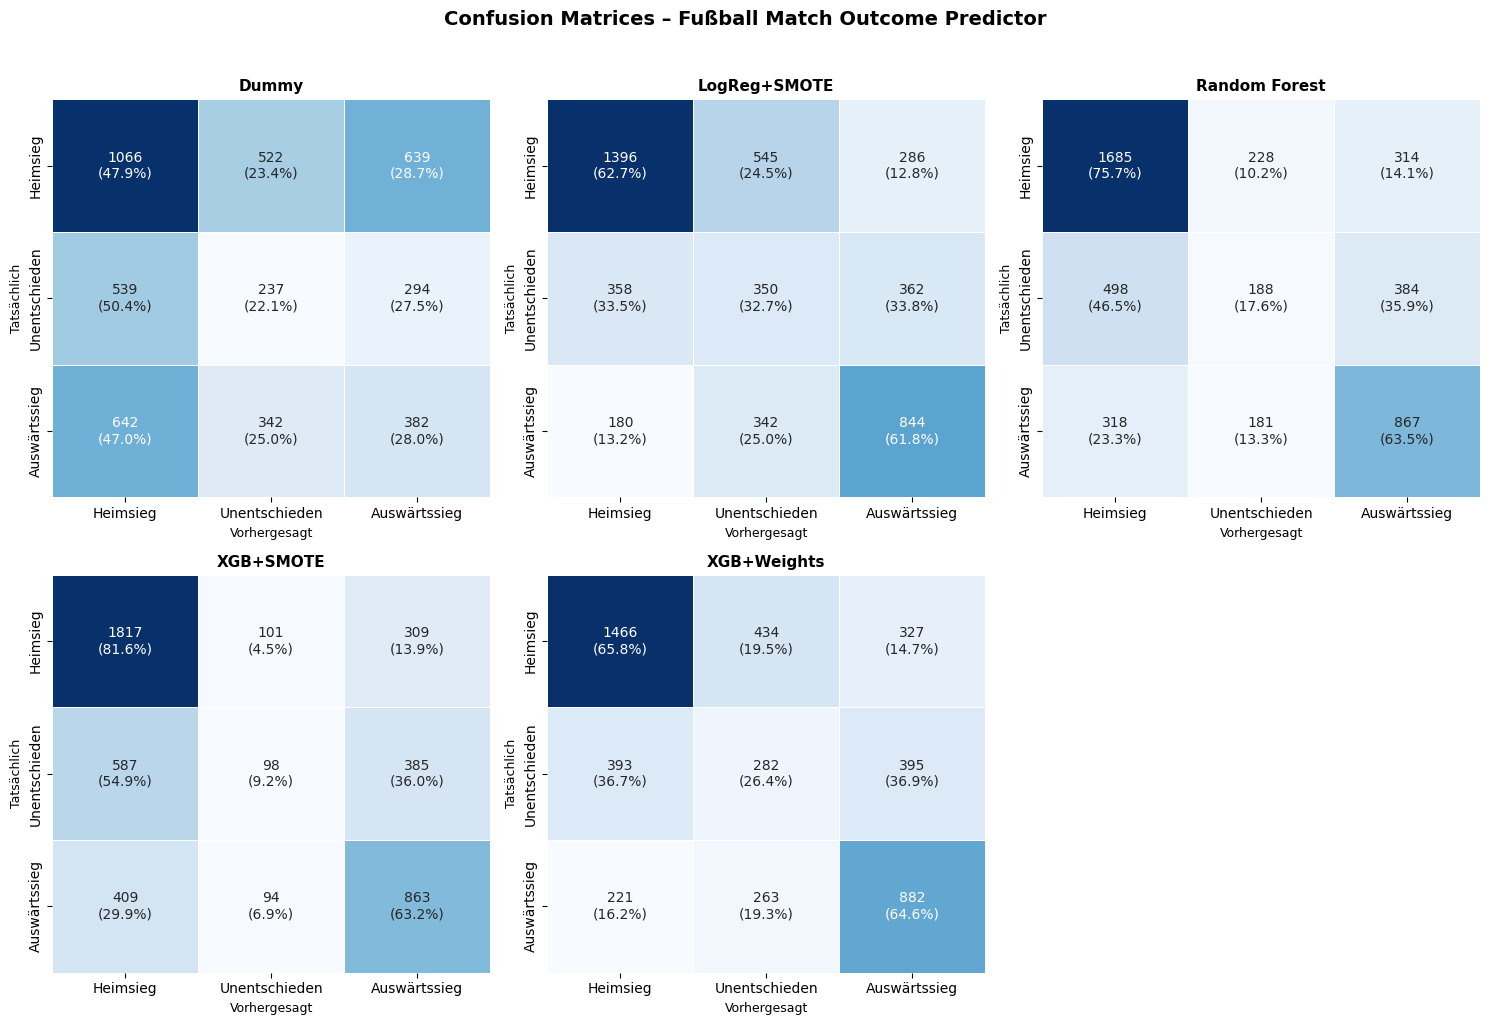

In [31]:
print("" + "─" * 60)
print("🎯 Confusion Matrices")
print("─" * 60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

class_names = ['Heimsieg', 'Unentschieden', 'Auswärtssieg']
colors = ['#888888', '#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for ax, (name, (_, y_pred, _)), color in zip(axes, models.items(), colors):
    cm = confusion_matrix(y_test, y_pred)

    # Prozentuale Werte für Annotation
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                cbar=False, linewidths=0.5, linecolor='white')

    # Füge Prozente hinzu
    for i in range(3):
        for j in range(3):
            text = ax.texts[i*3 + j]
            val = int(text.get_text())
            pct = cm_norm[i, j] * 100
            text.set_text(f"{val}\n({pct:.1f}%)")

    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Vorhergesagt', fontsize=9)
    ax.set_ylabel('Tatsächlich', fontsize=9)

# Entferne leere Subplots
for ax in axes[len(models):]:
    ax.axis('off')

plt.suptitle('Confusion Matrices – Fußball Match Outcome Predictor', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

os.makedirs(MODEL_DIR, exist_ok=True)
plt.savefig(f"{MODEL_DIR}/confusion_matrices.png", dpi=150, bbox_inches='tight')
print(f"✅ Gespeichert: {MODEL_DIR}/confusion_matrices.png")
plt.show()

# Feature Importance

────────────────────────────────────────────────────────────
🔍 Feature Importance
────────────────────────────────────────────────────────────
✅ Gespeichert: models_v2/feature_importance.png


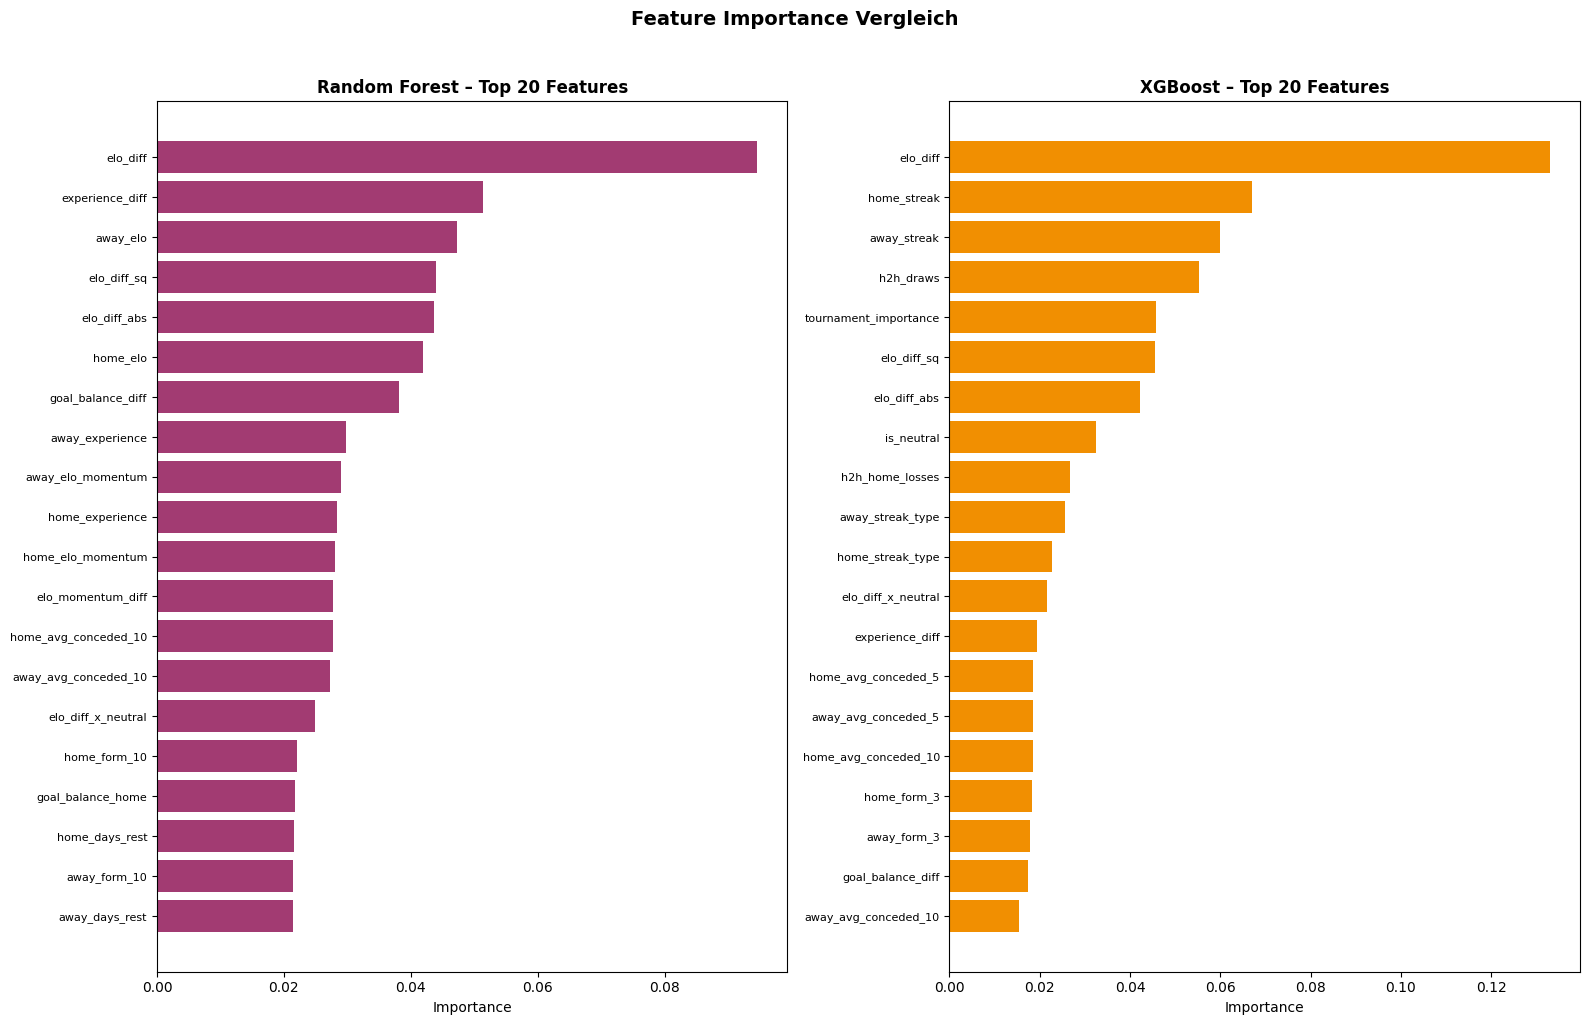

🏆 Top 10 – Random Forest:
          Feature  Importance
         elo_diff    0.094600
  experience_diff    0.051340
         away_elo    0.047256
      elo_diff_sq    0.043959
     elo_diff_abs    0.043596
         home_elo    0.041936
goal_balance_diff    0.038080
  away_experience    0.029790
away_elo_momentum    0.028959
  home_experience    0.028415
🏆 Top 10 – XGBoost:
              Feature  Importance
             elo_diff    0.133026
          home_streak    0.067019
          away_streak    0.059919
            h2h_draws    0.055201
tournament_importance    0.045852
          elo_diff_sq    0.045456
         elo_diff_abs    0.042286
           is_neutral    0.032511
      h2h_home_losses    0.026672
     away_streak_type    0.025615


In [32]:
print("" + "─" * 60)
print("🔍 Feature Importance")
print("─" * 60)

# Random Forest Importance
rf_model = models['Random Forest'][0]
rf_importance = rf_model.named_steps['clf'].feature_importances_
rf_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_importance
}).sort_values('Importance', ascending=False)

# XGBoost (SMOTE) Importance
xgb_model = models['XGB+SMOTE'][0]
xgb_importance = xgb_model.named_steps['clf'].feature_importances_
xgb_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_importance
}).sort_values('Importance', ascending=False)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

top_n = 20

# Random Forest
rf_top = rf_imp_df.head(top_n)
axes[0].barh(rf_top['Feature'][::-1], rf_top['Importance'][::-1], color='#A23B72')
axes[0].set_title(f'Random Forest – Top {top_n} Features', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Importance', fontsize=10)
axes[0].tick_params(axis='y', labelsize=8)

# XGBoost
xgb_top = xgb_imp_df.head(top_n)
axes[1].barh(xgb_top['Feature'][::-1], xgb_top['Importance'][::-1], color='#F18F01')
axes[1].set_title(f'XGBoost – Top {top_n} Features', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Importance', fontsize=10)
axes[1].tick_params(axis='y', labelsize=8)

plt.suptitle('Feature Importance Vergleich', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/feature_importance.png", dpi=150, bbox_inches='tight')
print(f"✅ Gespeichert: {MODEL_DIR}/feature_importance.png")
plt.show()

# Tabellarische Ausgabe
print("🏆 Top 10 – Random Forest:")
print(rf_imp_df.head(10).to_string(index=False))

print("🏆 Top 10 – XGBoost:")
print(xgb_imp_df.head(10).to_string(index=False))


# Korrelationsmatrix

────────────────────────────────────────────────────────────
🔗 Korrelationsmatrix (Top 15 Features)
────────────────────────────────────────────────────────────
✅ Gespeichert: models_v2/correlation_matrix.png


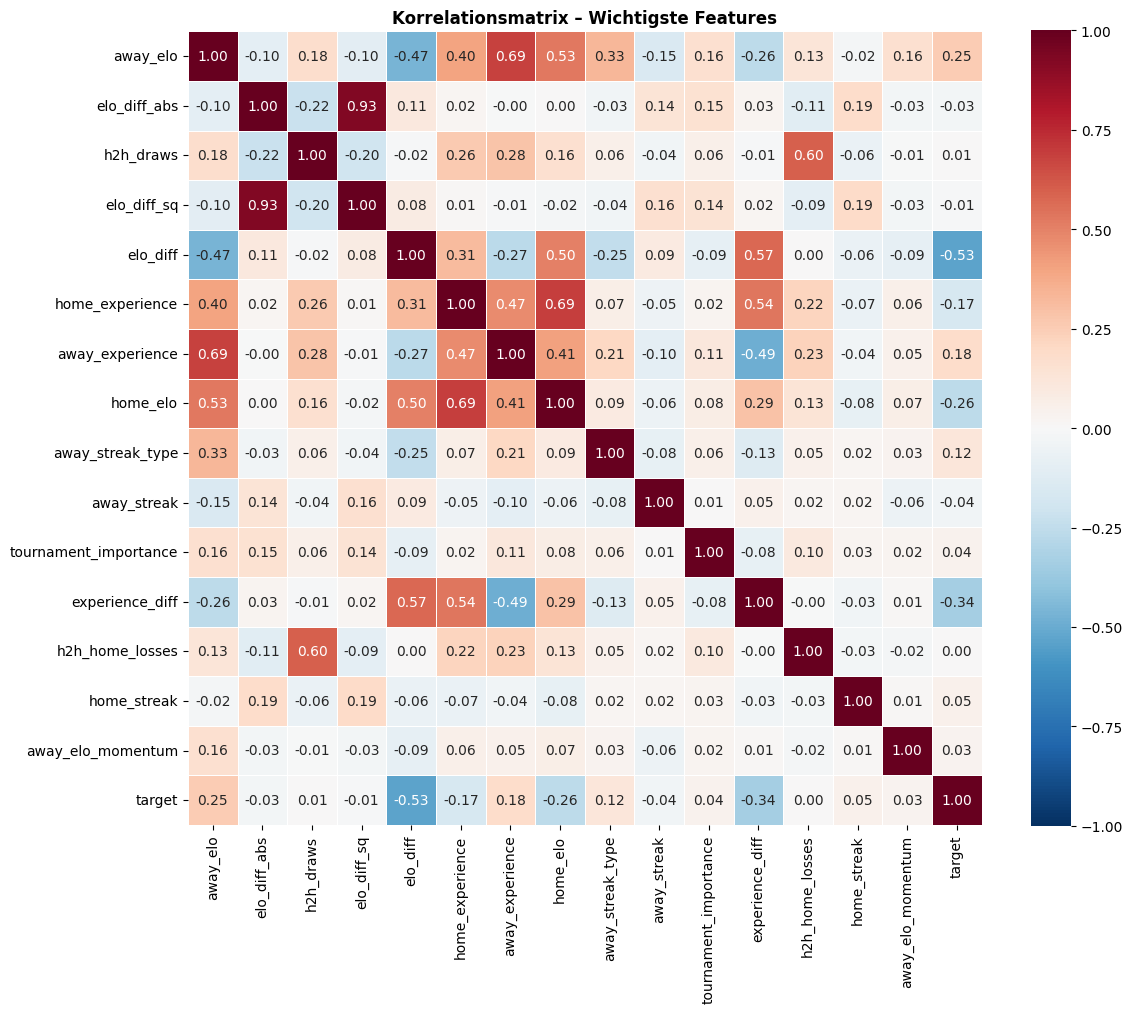

In [33]:
print("" + "─" * 60)
print("🔗 Korrelationsmatrix (Top 15 Features)")
print("─" * 60)

# Wähle Top 15 Features aus beiden Modellen
top_features = list(set(rf_imp_df.head(10)['Feature'].tolist() + 
                        xgb_imp_df.head(10)['Feature'].tolist()))[:15]
top_features.append(target_col)

corr_df = test_df[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Korrelationsmatrix – Wichtigste Features', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/correlation_matrix.png", dpi=150, bbox_inches='tight')
print(f"✅ Gespeichert: {MODEL_DIR}/correlation_matrix.png")
plt.show()

# Modelle speichern

In [35]:
print("💾 Speichern...")

os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(rf, f"{MODEL_DIR}/random_forest_best.pkl")
joblib.dump(xgb_smote, f"{MODEL_DIR}/xgboost_smote_best.pkl")
joblib.dump(xgb_w, f"{MODEL_DIR}/xgboost_weighted_best.pkl")
joblib.dump(lr, f"{MODEL_DIR}/logreg_smote_best.pkl")
joblib.dump(preprocessor, f"{MODEL_DIR}/preprocessor.pkl")
pd.DataFrame({'feature': feature_cols}).to_csv(f"{MODEL_DIR}/feature_list.csv", index=False)
res_df.to_csv(f"{MODEL_DIR}/model_results.csv", index=False)

print(f"✅ Alle Modelle & Ergebnisse gespeichert in {MODEL_DIR}/")

print("" + "=" * 60)
print("✅  Modelltraining v2 abgeschlossen!")
print("=" * 60)
print(f"Gespeicherte Dateien:")
print(f"  • confusion_matrices.png")
print(f"  • feature_importance.png")
print(f"  • correlation_matrix.png")
print(f"  • model_results.csv")
print(f"  • *.pkl Modelle")

💾 Speichern...
✅ Alle Modelle & Ergebnisse gespeichert in models_v2/
✅  Modelltraining v2 abgeschlossen!
Gespeicherte Dateien:
  • confusion_matrices.png
  • feature_importance.png
  • correlation_matrix.png
  • model_results.csv
  • *.pkl Modelle
